#Steps used
1. Loading IMDB Movie Reviews dataset
2. Dataset pre-processing by removing special characters, numbers etc. and changing sentiment labels positive and negative to numbers 1 and 0 respectively
3. Build Embedding dictionary by importing GloVe Word Embedding and use this to build Embedding Matrix for our Corpus
4. Training Model using Deep Learning in Keras for : CNN and LSTM Models and transformer model performance and results


#References
1. https://medium.com/analytics-vidhya/word-embeddings-in-nlp-word2vec-glove-fasttext-24d4d4286a73
2. https://medium.com/@mrunal68/text-sentiments-classification-with-cnn-and-lstm-f92652bc29fd

# setting the environment

In [ ]:
#Mounting google drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#setting toolkit folder as working directory
%cd /content/drive/My Drive/sentiment_analysis_with_neural_networks/
!ls


/content/drive/My Drive/sentiment_analysis_with_neural_networks
a1_IMDB_Dataset.csv   a3_IMDb_Unseen_Reviews.csv  imdb_reviews.csv
a2_glove.6B.100d.txt  c1_lstm_model_acc_0.862.h5  Reviews.csv


In [ ]:
# Import essential libraries and functions

import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from numpy import array

from keras.preprocessing.text import one_hot, Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Activation, Dropout, Dense
from keras.layers import Flatten, GlobalMaxPooling1D, Embedding, Conv1D, LSTM
from sklearn.model_selection import train_test_split

**Loading Dataset**

In [ ]:
# Importing IMDb Movie Reviews dataset

movie_reviews = pd.read_csv("imdb_reviews.csv")

# dataset source: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In [ ]:
# Dataset exploration

movie_reviews.shape
movie_reviews.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
# Checking for missing values

movie_reviews.isnull().values.any()

False

<Axes: xlabel='sentiment', ylabel='count'>

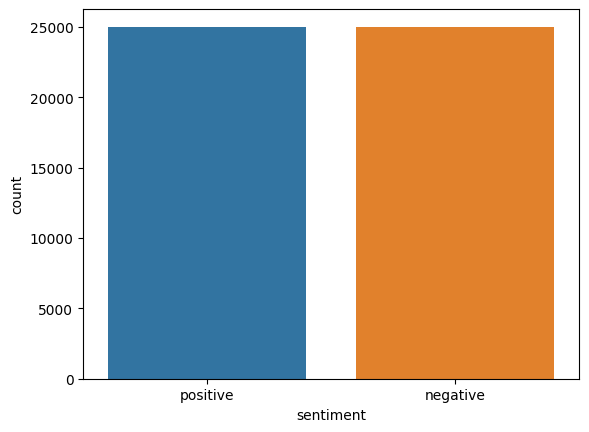

In [ ]:
# Let's observe distribution of positive / negative sentiments in dataset

import seaborn as sns
sns.countplot(x='sentiment', data=movie_reviews)

**#Data Preprocessing**

In [ ]:
movie_reviews["review"][5]

# the text contains punctuations, brackets, HTML tags and numbers
# this text will be processed in the next section

'Probably my all-time favorite movie, a story of selflessness, sacrifice and dedication to a noble cause, but it\'s not preachy or boring. It just never gets old, despite my having seen it some 15 or more times in the last 25 years. Paul Lukas\' performance brings tears to my eyes, and Bette Davis, in one of her very few truly sympathetic roles, is a delight. The kids are, as grandma says, more like "dressed-up midgets" than children, but that only makes them more fun to watch. And the mother\'s slow awakening to what\'s happening in the world and under her own roof is believable and startling. If I had a dozen thumbs, they\'d all be "up" for this movie.'

In [ ]:
#create compiled regular expression object for the pattern r'<[^>]+>'
TAG_RE = re.compile(r'<[^>]+>')

def remove_tags(text):
    '''Removes HTML tags: replaces anything between opening and closing <> with empty space'''

    return TAG_RE.sub('', text)

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
#clean and preprocess text

def preprocess_text(sen):
    '''Cleans text data up, leaving only 2 or more char long non-stepwords composed of A-Z & a-z only
    in lowercase'''

    sentence = sen.lower()

    # Remove html tags
    sentence = remove_tags(sentence)

    # Remove punctuations and numbers
    #replaces any character that is not a letter with space
    sentence = re.sub('[^a-zA-Z]', ' ', sentence)

    # Single character removal
    sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)  # When we remove apostrophe from the word "Tim's", the apostrophe is replaced by an empty space. Hence, left with single character "s" that is removed here.

    # Remove multiple spaces
    sentence = re.sub(r'\s+', ' ', sentence)           # remove all the single characters and replace it by a space which creates multiple spaces in the text. Finally, remove the multiple spaces from the text as well.

    # Remove Stopwords
    pattern = re.compile(r'\b(' + r'|'.join(stopwords.words('english')) + r')\b\s*')
    sentence = pattern.sub('', sentence)

    return sentence

In [ ]:
# Calling preprocessing_text function on movie_reviews

X = []
sentences = list(movie_reviews['review'])
for sen in sentences:
    X.append(preprocess_text(sen))

In [ ]:
# Sample cleaned up movie review

X[5]

# Word Embeddings is going to be used,so stemming/lemmatization is not performed as a preprocessing

'probably time favorite movie story selflessness sacrifice dedication noble cause preachy boring never gets old despite seen times last years paul lukas performance brings tears eyes bette davis one truly sympathetic roles delight kids grandma says like dressed midgets children makes fun watch mother slow awakening happening world roof believable startling dozen thumbs movie '

In [ ]:
# Converting sentiment labels to 0 & 1

y = movie_reviews['sentiment']

y = np.array(list(map(lambda x: 1 if x=="positive" else 0, y)))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# The train set to train the deep learning models
# test set to evaluate how well model performs

Preparing embedding layer

Embedding layer converts textual data into numerical form. Later it is used as the first layer for the deep learning models in keras.

In [ ]:
# Embedding layer expects the words to be in numeric form
# Using Tokenizer function from keras.preprocessing.text library
# Method fit_on_text trains the tokenizer
# Method texts_to_sequences converts sentences to their numeric form

word_tokenizer = Tokenizer()
word_tokenizer.fit_on_texts(X_train)

X_train = word_tokenizer.texts_to_sequences(X_train)
X_test = word_tokenizer.texts_to_sequences(X_test)

In [ ]:
# Adding 1 to store dimensions for words for which no pretrained word embeddings exist

vocab_length = len(word_tokenizer.word_index) + 1

vocab_length

92394

In [ ]:
# Padding all reviews to fixed length 100

maxlen = 100

X_train = pad_sequences(X_train, padding='post', maxlen=maxlen)
X_test = pad_sequences(X_test, padding='post', maxlen=maxlen)

In [ ]:
# Load GloVe word embeddings and create an Embeddings Dictionary

from numpy import asarray
from numpy import zeros

embeddings_dictionary = dict()
glove_file = open('a2_glove.6B.100d.txt', encoding="utf8")

for line in glove_file:
    records = line.split()
    word = records[0]
    vector_dimensions = asarray(records[1:], dtype='float32')
    embeddings_dictionary [word] = vector_dimensions
glove_file.close()

In [ ]:
# Create Embedding Matrix having 100 columns
# Containing 100-dimensional GloVe word embeddings for all words in our corpus.

embedding_matrix = zeros((vocab_length, 100))
for word, index in word_tokenizer.word_index.items():
    embedding_vector = embeddings_dictionary.get(word)
    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector

In [ ]:
embedding_matrix.shape

(92394, 100)

**Model Training with different Models**




**1. Convolutional Neural Network**

In [ ]:
from keras.layers import Conv1D

In [ ]:
# Neural Network architecture

cnn_model = Sequential()

embedding_layer = Embedding(vocab_length, 100, weights=[embedding_matrix], input_length=maxlen , trainable=False)
cnn_model.add(embedding_layer)

cnn_model.add(Conv1D(128, 5, activation='relu'))
cnn_model.add(GlobalMaxPooling1D())
cnn_model.add(Dense(1, activation='sigmoid'))

In [ ]:
# Model compiling

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
print(cnn_model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 100)          9239400   
                                                                 
 conv1d (Conv1D)             (None, 96, 128)           64128     
                                                                 
 global_max_pooling1d (Glob  (None, 128)               0         
 alMaxPooling1D)                                                 
                                                                 
 dense (Dense)               (None, 1)                 129       
                                                                 
Total params: 9303657 (35.49 MB)
Trainable params: 64257 (251.00 KB)
Non-trainable params: 9239400 (35.25 MB)
_________________________________________________________________
None


In [ ]:
# Model training

cnn_model_history = cnn_model.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

Epoch 1/6
250/250 [==============================] - 28s 108ms/step - loss: 0.4968 - acc: 0.7582 - val_loss: 0.3901 - val_acc: 0.8271
Epoch 2/6
250/250 [==============================] - 23s 92ms/step - loss: 0.3517 - acc: 0.8490 - val_loss: 0.3540 - val_acc: 0.8426
Epoch 3/6
250/250 [==============================] - 26s 106ms/step - loss: 0.2945 - acc: 0.8802 - val_loss: 0.3420 - val_acc: 0.8487
Epoch 4/6
250/250 [==============================] - 23s 90ms/step - loss: 0.2500 - acc: 0.9052 - val_loss: 0.3355 - val_acc: 0.8529
Epoch 5/6
250/250 [==============================] - 26s 104ms/step - loss: 0.2085 - acc: 0.9273 - val_loss: 0.3318 - val_acc: 0.8551
Epoch 6/6
250/250 [==============================] - 22s 90ms/step - loss: 0.1754 - acc: 0.9451 - val_loss: 0.3366 - val_acc: 0.8526


In [ ]:
#create prediction from X_test set and display classification report
#create confusion matrix for the X_test set
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

In [ ]:
y_pred  = cnn_model.predict(X_test)
y_pred_classes = np.round(y_pred)

313/313 [==============================] - 3s 9ms/step


In [ ]:
# Convert predictions and true labels to binary (0 or 1)
y_pred_classes = y_pred_classes.flatten()
y_test = y_test.flatten()

In [ ]:
# Generate the classification report
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.88      0.81      0.85      4961
           1       0.83      0.89      0.86      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [ ]:
# Predictions on the Test Set

score = cnn_model.evaluate(X_test, y_test, verbose=1)

313/313 [==============================] - 3s 9ms/step - loss: 0.3448 - acc: 0.8526


In [ ]:
# Model Performance

print("Test Score:", score[0])
print("Test Accuracy:", score[1])

Test Score: 0.3448199927806854
Test Accuracy: 0.8525999784469604


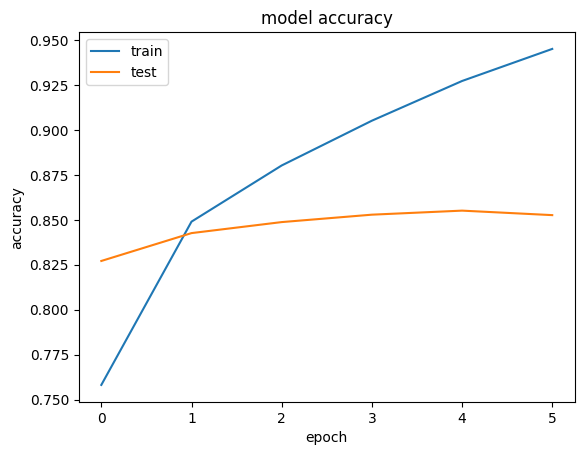

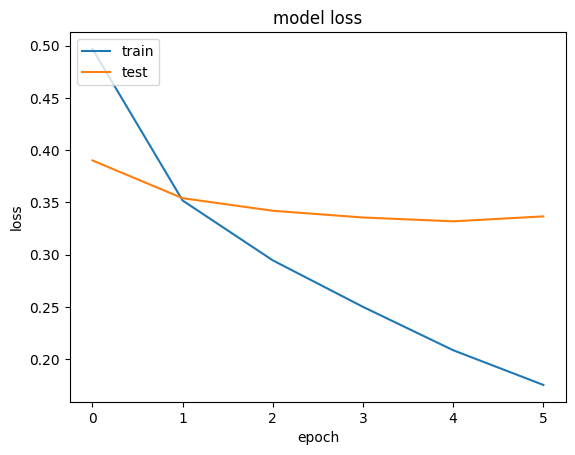

In [ ]:
# Model Performance Charts

import matplotlib.pyplot as plt

plt.plot(cnn_model_history.history['acc'])
plt.plot(cnn_model_history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc = 'upper left')
plt.show()

plt.plot(cnn_model_history.history['loss'])
plt.plot(cnn_model_history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc = 'upper left')
plt.show()

**2. Recurrent Neural Network: LSTM**

In [ ]:
from keras.layers import LSTM

In [ ]:
# Neural Network architecture

lstm_model = Sequential()
embedding_layer = Embedding(vocab_length, 100, weights=[embedding_matrix], input_length=maxlen , trainable=False)

lstm_model.add(embedding_layer)
lstm_model.add(LSTM(128))

lstm_model.add(Dense(1, activation='sigmoid'))

In [ ]:
# Model compiling

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])
print(lstm_model.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 100, 100)          9239400   
                                                                 
 lstm (LSTM)                 (None, 128)               117248    
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 9356777 (35.69 MB)
Trainable params: 117377 (458.50 KB)
Non-trainable params: 9239400 (35.25 MB)
_________________________________________________________________
None


In [ ]:
# Model Training

lstm_model_history = lstm_model.fit(X_train, y_train, batch_size=128, epochs=6, verbose=1, validation_split=0.2)

Epoch 1/6
250/250 [==============================] - 80s 310ms/step - loss: 0.5125 - acc: 0.7496 - val_loss: 0.4241 - val_acc: 0.8112
Epoch 2/6
250/250 [==============================] - 76s 304ms/step - loss: 0.4124 - acc: 0.8166 - val_loss: 0.3768 - val_acc: 0.8317
Epoch 3/6
250/250 [==============================] - 77s 309ms/step - loss: 0.3705 - acc: 0.8385 - val_loss: 0.3481 - val_acc: 0.8534
Epoch 4/6
250/250 [==============================] - 75s 301ms/step - loss: 0.3409 - acc: 0.8553 - val_loss: 0.3428 - val_acc: 0.8486
Epoch 5/6
250/250 [==============================] - 78s 313ms/step - loss: 0.3243 - acc: 0.8643 - val_loss: 0.3394 - val_acc: 0.8634
Epoch 6/6
250/250 [==============================] - 78s 312ms/step - loss: 0.3059 - acc: 0.8731 - val_loss: 0.3165 - val_acc: 0.8640


In [ ]:
y_pred  = lstm_model.predict(X_test)
y_pred_classes = np.round(y_pred)

313/313 [==============================] - 17s 54ms/step


In [ ]:
# Convert predictions and true labels to binary (0 or 1)
y_pred_classes = y_pred_classes.flatten()
y_test = y_test.flatten()

In [ ]:
# Generate the classification report
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.87      0.86      0.86      4961
           1       0.86      0.87      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [ ]:
# Predictions on the Test Set

score = lstm_model.evaluate(X_test, y_test, verbose=1)

313/313 [==============================] - 17s 53ms/step - loss: 0.3127 - acc: 0.8661


In [ ]:
# Model Performance

print("Test Score:", score[0])
print("Test Accuracy:", score[1])

Test Score: 0.31270265579223633
Test Accuracy: 0.866100013256073


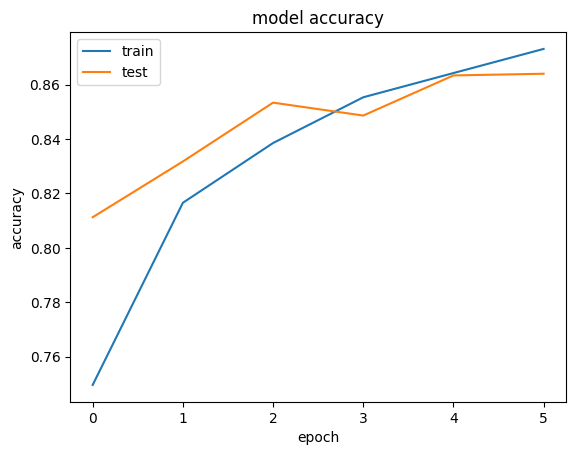

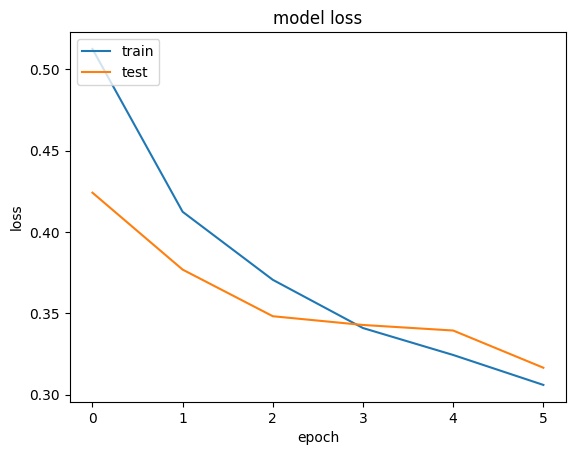

In [ ]:
# Model Performance Charts

import matplotlib.pyplot as plt

plt.plot(lstm_model_history.history['acc'])
plt.plot(lstm_model_history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

plt.plot(lstm_model_history.history['loss'])
plt.plot(lstm_model_history.history['val_loss'])

plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'], loc='upper left')
plt.show()

In [ ]:
# Saving the model as a h5 file for possible use later

lstm_model.save(f"./c1_lstm_model_acc_{round(score[1], 3)}.h5", save_format='h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
